In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h = 0.1 # step size
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h)
x_values = np.linspace(x_start, x_end, num_steps +
1)
y_values = np.zeros(num_steps + 1)

# Initial condition
y_values[0] = 1 # y(0) = 1
# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

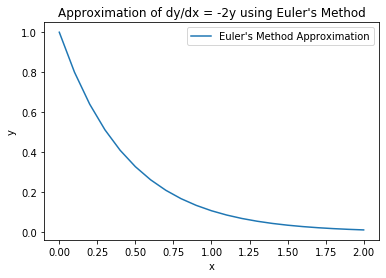

In [2]:
# Implement Euler's method
for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

# Plot the results
plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()

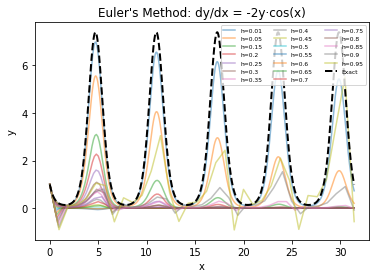

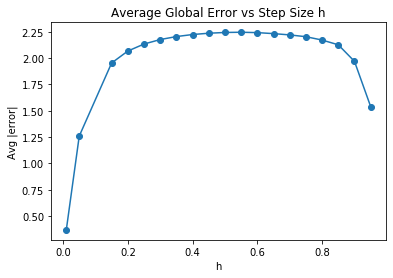

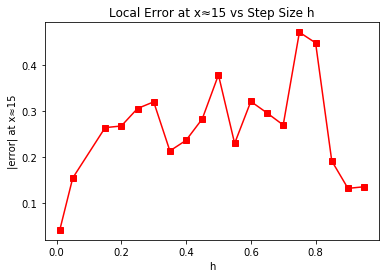

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 10 * np.pi

def f(x, y):
    return -2 * y * np.cos(x)         # NEW: cos(x) term

def exact(x):
    return np.exp(-2 * np.sin(x))     # analytical solution

# Step sizes from homework
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.3, 0.35,
            0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7,
            0.75, 0.8, 0.85, 0.9, 0.95]

avg_errors = []
local_errors_at_15 = []

fig1, ax1 = plt.subplots()  # Plot 1: all Euler runs

for h in h_values:
    num_steps = int((x_end - x_start) / h)
    x_vals = np.linspace(x_start, x_end, num_steps + 1)
    y_vals = np.zeros(num_steps + 1)
    y_vals[0] = 1.0

    # Euler loop
    for i in range(num_steps):
        y_vals[i+1] = y_vals[i] + h * f(x_vals[i], y_vals[i])

    # Exact solution at same x points
    y_exact = exact(x_vals)

    # Global error (average)
    error = np.abs(y_vals - y_exact)
    avg_errors.append(np.mean(error))

    # Local error near x = 15
    idx = np.argmin(np.abs(x_vals - 15.0))
    local_errors_at_15.append(np.abs(y_vals[idx] - y_exact[idx]))

    ax1.plot(x_vals, y_vals, alpha=0.5, label=f'h={h}')

# Finish Plot 1
y_fine = exact(np.linspace(x_start, x_end, 5000))
ax1.plot(np.linspace(x_start, x_end, 5000), y_fine,
         'k--', linewidth=2, label='Exact')
ax1.set_title("Euler's Method: dy/dx = -2y·cos(x)")
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.legend(fontsize=6, ncol=3)

# Plot 2: Avg error vs h
fig2, ax2 = plt.subplots()
ax2.plot(h_values, avg_errors, 'o-')
ax2.set_title('Average Global Error vs Step Size h')
ax2.set_xlabel('h'); ax2.set_ylabel('Avg |error|')

# Plot 3: Local error at x≈15 vs h
fig3, ax3 = plt.subplots()
ax3.plot(h_values, local_errors_at_15, 's-', color='red')
ax3.set_title('Local Error at x≈15 vs Step Size h')
ax3.set_xlabel('h'); ax3.set_ylabel('|error| at x≈15')

plt.show()